# creating a supervised model for heart disease

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##  1. Data Loading and Inspection

In [2]:
df = pd.read_csv('..\\data\\q1_heart_disease.csv')
# display shape
print("Shape of the dataset:")
df.shape

Shape of the dataset:


(800, 12)

In [3]:
# display data types
print("Data types:")
df.dtypes

Data types:


age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

In [4]:
# display null values
print("Null values:")
df.isnull().sum()

Null values:


age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

In [5]:
# display first 5 rows
print("First 5 rows:")
df.head()


First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis

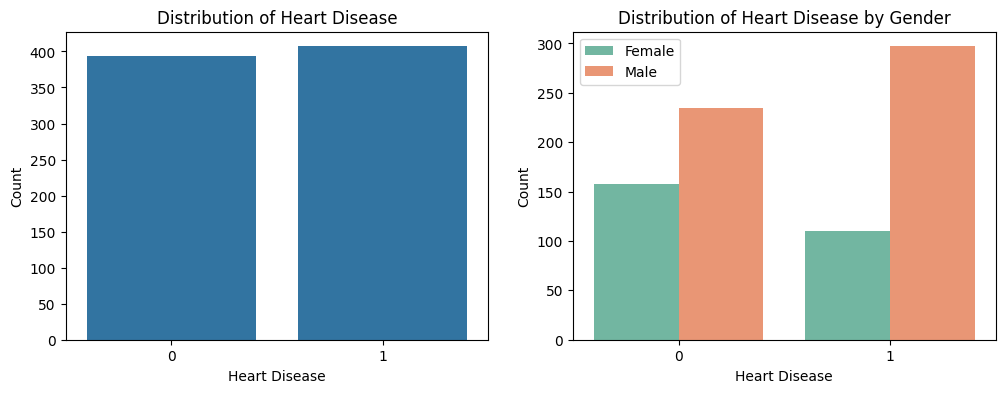

In [6]:
# Produce at least three visualisations — include at minimum a target class distribution plot and a correlation heatmap.

# creating 2 bar graphs for the distribution of heart disease and disease by sex

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='heart_disease', data=df)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.xticks(rotation=0)

# plt.show()
plt.subplot(1, 2, 2)
sns.countplot(x='heart_disease', data=df,hue='sex', palette='Set2')
plt.title('Distribution of Heart Disease by Gender')
plt.xlabel('Heart Disease')
plt.legend(['Female', 'Male'])
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [7]:
# mapping the categorical variables to numerical values and add new columns to the dataframe
df['Chest_Pain_Int'] = df['chest_pain_type'].map({'typical_angina': 0, 'atypical_angina': 1, 'non_anginal': 2, 'asymptomatic': 3})
df['resting_ecg_int'] = df['resting_ecg'].map({'normal': 0, 'st_t_wave_abnormality': 1, 'left_ventricular_hypertrophy': 2})
df['st_slope_int'] = df['st_slope'].map({'up': 0, 'flat': 1, 'down': 2})

In [8]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
       'fasting_bs', 'resting_ecg', 'max_hr', 'exercise_angina', 'oldpeak',
       'st_slope', 'heart_disease', 'Chest_Pain_Int', 'resting_ecg_int',
       'st_slope_int'],
      dtype='str')

In [9]:
df.dtypes

age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
Chest_Pain_Int       int64
resting_ecg_int      int64
st_slope_int         int64
dtype: object

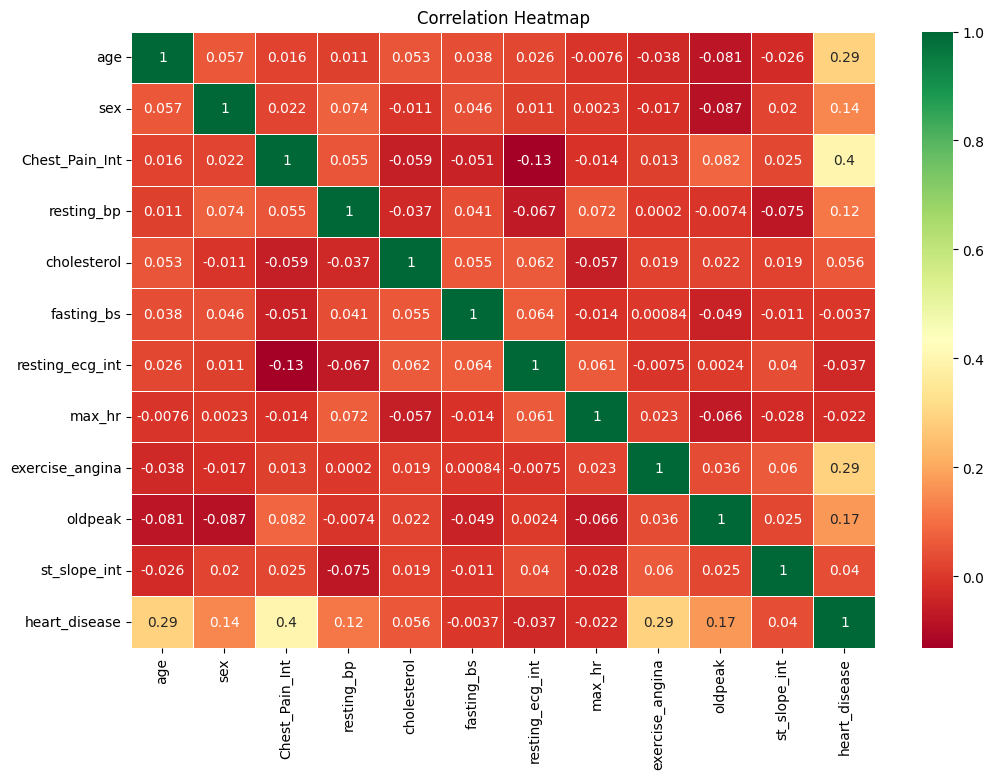

In [10]:
# creating a correlation heatmap to show the correlation between the features and the target variable
plt.figure(figsize=(12, 8))
cols = ['age', 'sex', 'Chest_Pain_Int', 'resting_bp', 'cholesterol', 'fasting_bs', 'resting_ecg_int', 'max_hr', 'exercise_angina', 'oldpeak', 'st_slope_int', 'heart_disease']
sns.heatmap(df[cols].corr(), annot=True, cmap='RdYlGn', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

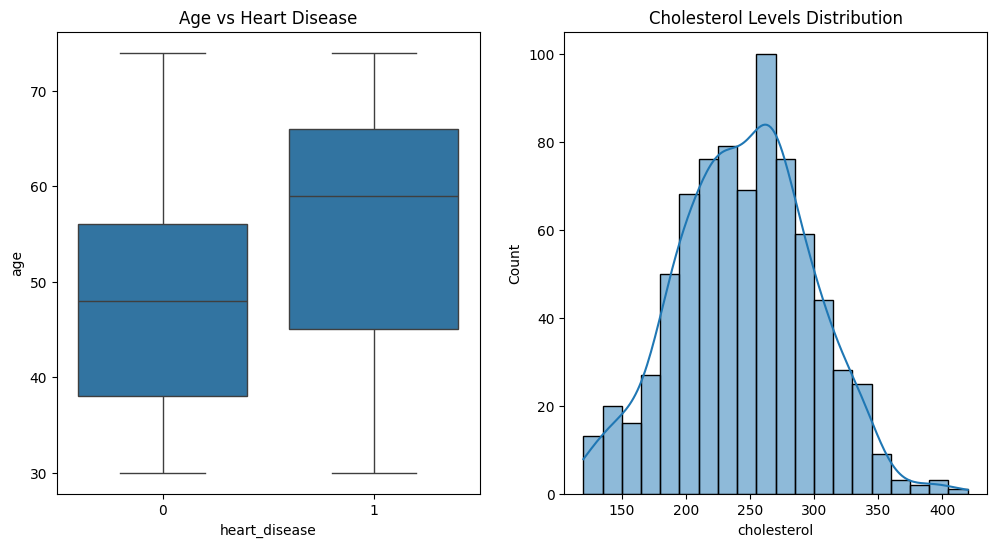

In [11]:
#add subplots for 2 plots
# Age vs Heart Disease
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
# plt.show()

# count cholestrol levels by heart disease
plt.subplot(1, 2, 2)
sns.histplot(df['cholesterol'], kde=True)
plt.title("Cholesterol Levels Distribution")
plt.show()



In [12]:
# cre
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
       'fasting_bs', 'resting_ecg', 'max_hr', 'exercise_angina', 'oldpeak',
       'st_slope', 'heart_disease', 'Chest_Pain_Int', 'resting_ecg_int',
       'st_slope_int'],
      dtype='str')

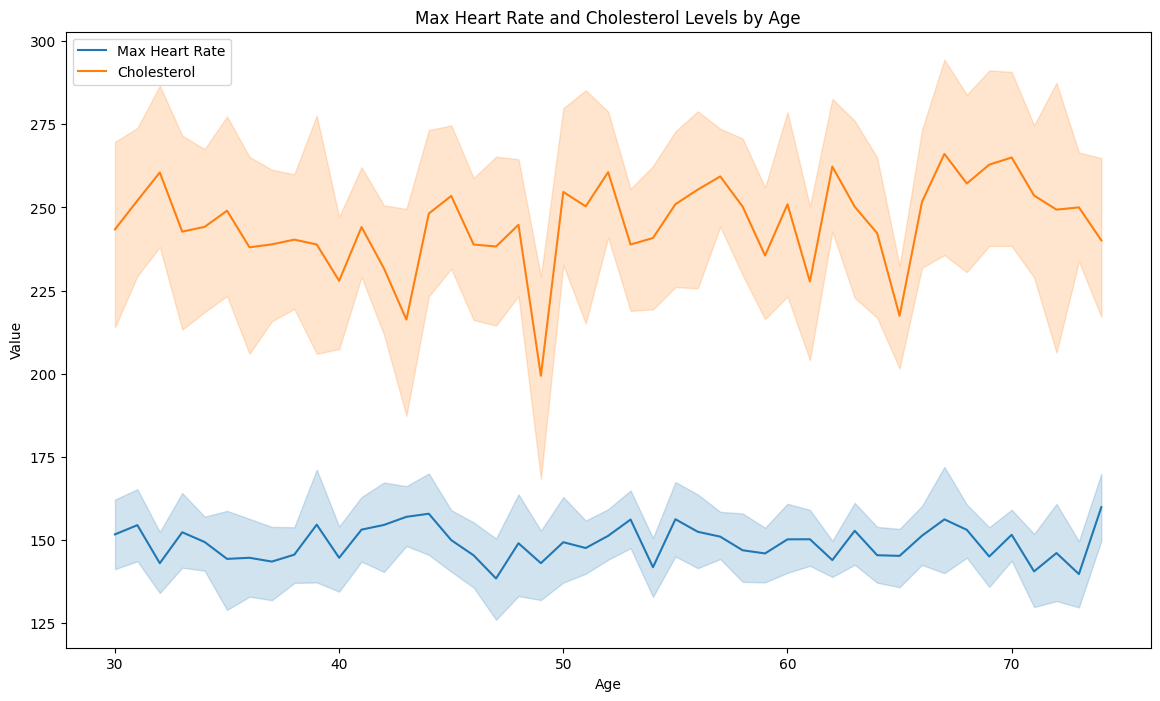

In [13]:
# creating a line plot to show the relationship between age and maximum heart rate achieved + Cholesterol levels
plt.figure(figsize=(14, 8))
sns.lineplot(x='age', y='max_hr', data=df, label='Max Heart Rate')
sns.lineplot(x='age', y='cholesterol', data=df, label='Cholesterol')
plt.title('Max Heart Rate and Cholesterol Levels by Age')
plt.xlabel('Age')
plt.ylabel('Value')
plt.show()

## 3. Data Preprocessing

In [14]:
df.describe()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,Chest_Pain_Int,resting_ecg_int,st_slope_int
count,800.000000,800.000000,776.000000,768.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,52.191250,0.665000,130.668814,245.622396,0.23250,149.145000,0.295000,0.925500,0.508750,2.150000,0.622500,0.692500
std,12.862211,0.472286,16.408805,52.185464,0.42269,22.396394,0.456328,0.897612,0.500236,0.976572,0.702218,0.754092
min,30.000000,0.000000,90.000000,120.000000,0.00000,76.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,120.000000,209.000000,0.00000,134.000000,0.000000,0.300000,0.000000,1.000000,0.000000,0.000000
50%,53.000000,1.000000,130.000000,247.000000,0.00000,149.000000,0.000000,0.600000,1.000000,2.000000,0.000000,1.000000
75%,63.000000,1.000000,142.000000,279.250000,0.00000,165.000000,1.000000,1.300000,1.000000,3.000000,1.000000,1.000000
max,74.000000,1.000000,184.000000,420.000000,1.00000,202.000000,1.000000,5.700000,1.000000,3.000000,2.000000,2.000000


In [15]:
# Filling the missing values Using mean for resting_bp and median for cholesterol
df['resting_bp'] = df['resting_bp'].fillna(round(df['resting_bp'].mean(), 2))
# used mean because the distribution of resting_bp is normal and there are no outliers
df['cholesterol'] = df['cholesterol'].fillna(round(df['cholesterol'].median(), 2))
# used median because the distribution of cholesterol is skewed and there are outliers
df.isna().sum()

age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
Chest_Pain_Int     0
resting_ecg_int    0
st_slope_int       0
dtype: int64

In [16]:
df = df.drop(columns=['chest_pain_type', 'resting_ecg', 'st_slope'])

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   resting_bp       800 non-null    float64
 3   cholesterol      800 non-null    float64
 4   fasting_bs       800 non-null    int64  
 5   max_hr           800 non-null    int64  
 6   exercise_angina  800 non-null    int64  
 7   oldpeak          800 non-null    float64
 8   heart_disease    800 non-null    int64  
 9   Chest_Pain_Int   800 non-null    int64  
 10  resting_ecg_int  800 non-null    int64  
 11  st_slope_int     800 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 75.1 KB


In [18]:
df.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,Chest_Pain_Int,resting_ecg_int,st_slope_int
0,68,0,142.0,399.0,0,169,0,0.4,1,1,2,0
1,58,1,163.0,310.0,1,121,1,1.1,1,2,1,0
2,44,1,128.0,175.0,0,183,1,0.2,0,2,0,0
3,72,1,114.0,177.0,0,150,0,1.0,1,3,1,0
4,37,1,149.0,271.0,0,136,0,0.4,0,2,0,1


In [19]:
# standard scaling the numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_features = ['age', 'resting_bp', 'cholesterol', 'max_hr']
df[numerical_features] = scaler.fit_transform(df[numerical_features])


In [20]:
df.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,Chest_Pain_Int,resting_ecg_int,st_slope_int
0,1.229854,0,0.701603,3.000527,0,0.887081,0,0.4,1,1,2,0
1,0.451896,1,2.001881,1.258794,1,-1.257462,1,1.1,1,2,1,0
2,-0.637245,1,-0.165250,-1.383161,0,1.512573,1,0.2,0,2,0,0
3,1.541037,1,-1.032102,-1.344021,0,0.038200,0,1.0,1,3,1,0
4,-1.181815,1,1.135029,0.495562,0,-0.587292,0,0.4,0,2,0,1


## 4. Model Training & 5. Model Evaluation 

In [21]:
df.columns

Index(['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr',
       'exercise_angina', 'oldpeak', 'heart_disease', 'Chest_Pain_Int',
       'resting_ecg_int', 'st_slope_int'],
      dtype='str')

In [22]:
# Split data using train_test_split with stratify=y and random_state=42
from sklearn.model_selection import train_test_split
X = df.drop(columns=['heart_disease'])
y = df['heart_disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Create and fit the model
decision_model = DecisionTreeClassifier(random_state=42)
decision_model.fit(X_train, y_train)
# Predict on the test set
y_pred = decision_model.predict(X_test)
# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred)*100, "%")

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.73      0.72        79
           1       0.73      0.69      0.71        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160

Confusion Matrix:
[[58 21]
 [25 56]]
Accuracy Score: 71.25 %


In [24]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
# Create and fit the model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
# Predict on the test set
y_pred = gb_model.predict(X_test)
# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred)*100, "%")


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78        79
           1       0.79      0.79      0.79        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Confusion Matrix:
[[62 17]
 [17 64]]
Accuracy Score: 78.75 %


In [25]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Create and fit the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred)*100, "%")


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        79
           1       0.80      0.80      0.80        81

    accuracy                           0.80       160
   macro avg       0.80      0.80      0.80       160
weighted avg       0.80      0.80      0.80       160

Confusion Matrix:
[[63 16]
 [16 65]]
Accuracy Score: 80.0 %


## 6. Hyperparameter Tuning

In [26]:
#tunning
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "min_samples_leaf": [1, 2, 4]
}
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1, refit=True, scoring='accuracy')
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [27]:
# best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 100}


In [28]:

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Tuned Model Performance")
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Tuned Model Performance
[[62 17]
 [16 65]]
              precision    recall  f1-score   support

           0       0.79      0.78      0.79        79
           1       0.79      0.80      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

